# 1.0. Setup (RUN)

In [ ]:
# ============================================================
# SECTION 0 — Setup (RUN)
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

!pip -q install mne mne-icalabel numpy scipy pandas matplotlib scikit-learn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 13.1 MB/s eta 0:00:00


# 1.1. Imports & Configuration (RUN)

In [ ]:
# ============================================================
# SECTION 1 — Imports & Configuration (RUN)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import mne
from mne.preprocessing import ICA
from mne.time_frequency import psd_array_welch
from mne_icalabel import label_components

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------- PATHS (EDIT) --------------------
SET_DIR = Path("/content/drive/MyDrive/EEG")           # .set files
OUT_DIR = Path("/content/drive/MyDrive/EEG_processed_auto")      # outputs
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- CHANNELS (KEEP ALL 14) --------------------
EEG_CHANNELS = [
    "AF3","AF4","F3","F4","F7","F8","FC5","FC6","T7","T8","P7","P8","O1","O2"
]

# -------------------- PREPROCESSING --------------------
TARGET_SFREQ = 128
LINE_FREQ = 50
BANDPASS = (2.0, 30.0)  # optimized for SNR

# -------------------- ICA (AUTOMATIC) --------------------
ICA_HP_FREQ = 1.0
ICA_NCOMP = 0.99
ICLABEL_THRESHOLD = 0.50  # aggressive artifact removal
ARTIFACT_CLASSES = {"eye blink","muscle artifact","heart beat","line noise","channel noise"}

# -------------------- BAD SEGMENT DETECTION --------------------
BADSEG_ZTHRESH = 6.0 #8 ideal
BADSEG_MIN_DURATION = 0.20 #.20 ideal

# If too many windows are dropped, we will auto-detect bad channels and interpolate
MIN_KEEP_RATIO = 0.65          # if kept epochs < 60% expected => trigger interpolation -60to70 ideal
MAX_BAD_CH_TO_INTERP = 3       # interpolate at most this many channels automatically -2 Idea case
BADCH_FRAC_THRESH = 0.01       # fraction of samples exceeding threshold => noisy channel - 0.01 ideal

# -------------------- WINDOWING --------------------
WIN_SEC = 8.0
OVERLAP_SEC = 4.0
STEP_SEC = WIN_SEC - OVERLAP_SEC

# -------------------- FEATURE BANDS --------------------
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}

# 2.0. Utility Functions (RUN)

In [ ]:
# ============================================================
# SECTION 2 — Utility Functions (RUN)
# ============================================================
def expected_epoch_count(raw, win_sec, step_sec):
    T = raw.times[-1]  # seconds
    if T < win_sec:
        return 0
    return int(np.floor((T - win_sec) / step_sec) + 1)

def annotate_high_amplitude(raw_in, picks, z_thresh=8.0, min_duration=0.2, desc="BAD_amp"):
    """Robust high-amplitude detector using MAD; annotates contaminated time segments."""
    r = raw_in.copy().pick(picks=picks)
    data = r.get_data()  # (n_ch, n_times)

    med = np.median(data, axis=1, keepdims=True)
    mad = np.median(np.abs(data - med), axis=1, keepdims=True) + 1e-20

    # max z across channels (time-wise)
    z = np.max(np.abs((data - med) / mad), axis=0)
    bad = z > z_thresh

    times = r.times
    onsets, durations = [], []
    in_bad = False
    start_t = None

    for i, b in enumerate(bad):
        if b and not in_bad:
            in_bad = True
            start_t = times[i]
        elif (not b) and in_bad:
            in_bad = False
            end_t = times[i]
            if (end_t - start_t) >= min_duration:
                onsets.append(start_t)
                durations.append(end_t - start_t)

    if in_bad:
        end_t = times[-1]
        if (end_t - start_t) >= min_duration:
            onsets.append(start_t)
            durations.append(end_t - start_t)

    if len(onsets) > 0:
        ann = mne.Annotations(onsets, durations, [desc] * len(onsets))
        raw_in.set_annotations(raw_in.annotations + ann)

    return raw_in

def noisy_channel_scores(raw_in, picks, z_thresh=8.0):
    """
    Score channels by fraction of samples exceeding robust z-threshold.
    Higher fraction = noisier channel.
    """
    r = raw_in.copy().pick(picks=picks)
    data = r.get_data()
    med = np.median(data, axis=1, keepdims=True)
    mad = np.median(np.abs(data - med), axis=1, keepdims=True) + 1e-20
    z = np.abs((data - med) / mad)  # (n_ch, n_times)
    frac = np.mean(z > z_thresh, axis=1)
    return dict(zip(r.ch_names, frac))

def make_epochs_clean(raw_in):
    """Create fixed-length epochs with reject_by_annotation."""
    epochs = mne.make_fixed_length_epochs(
        raw_in, duration=WIN_SEC, overlap=OVERLAP_SEC,
        preload=True, reject_by_annotation=True
    )
    return epochs

def ensure_montage_available(raw_in):
    """
    Interpolation needs channel positions. In EEGLAB .set, these often exist.
    This function checks montage/dig and raises a clear error if missing.
    """
    montage = raw_in.get_montage()
    if montage is not None:
        return True

    # Sometimes positions are in info['chs'][i]['loc'] but montage object is None
    loc_ok = True
    for ch in raw_in.info["chs"]:
        loc = ch["loc"][:3]
        if np.allclose(loc, 0) or np.any(~np.isfinite(loc)):
            loc_ok = False
            break

    if not loc_ok:
        return False
    return True

# 3.0. Load .set (RUN)

In [ ]:
# ============================================================
# SECTION 3 — Load .set (RUN)
# ============================================================
set_files = sorted(SET_DIR.glob("*.set"))
if len(set_files) == 0:
    raise FileNotFoundError(f"No .set files found in: {SET_DIR}")

set_path = set_files[3]  # change index for other subjects
print("Loading:", set_path.name)

raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose="ERROR")
raw.pick(picks="eeg")

# Keep exactly the 14 channels if they exist
missing = [ch for ch in EEG_CHANNELS if ch not in raw.ch_names]
if missing:
    print("WARNING: These channels are missing in the file:", missing)

keep = [ch for ch in EEG_CHANNELS if ch in raw.ch_names]
raw.pick_channels(keep)

print(raw)
print("Channels kept:", raw.ch_names)
print("sfreq:", raw.info["sfreq"])

Loading: S4EDFN.set
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
<RawEEGLAB | S4EDFN.fdt, 14 x 46720 (365.0 s), ~5.0 MiB, data loaded>
Channels kept: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
sfreq: 128.0


# 4.0. Preprocessing (RUN)

In [ ]:
# ============================================================
# SECTION 4 — Preprocessing (RUN)
# ============================================================
raw.resample(TARGET_SFREQ)
raw.notch_filter(freqs=[LINE_FREQ], picks="eeg")
raw.filter(l_freq=BANDPASS[0], h_freq=BANDPASS[1], picks="eeg")
raw.set_eeg_reference("average", projection=False)

print("Preprocessing done. sfreq =", raw.info["sfreq"])

Sampling frequency of the instance is already 128.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 845 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transitio

# 5.0. Automatic ICA (ICLabel) Artifact Removal (RUN)

In [ ]:
# ============================================================
# SECTION 5 — Automatic ICA (ICLabel) Artifact Removal (RUN)
# ============================================================
raw_for_ica = raw.copy().filter(l_freq=ICA_HP_FREQ, h_freq=None, picks="eeg")

ica = ICA(n_components=ICA_NCOMP, method="fastica", random_state=42, max_iter="auto")
ica.fit(raw_for_ica)

labels = label_components(raw, ica, method="iclabel")
ic_labels = labels["labels"]
ic_proba  = labels["y_pred_proba"]

exclude = []
for i, lab in enumerate(ic_labels):
    conf = float(ic_proba[i].max())
    if (lab in ARTIFACT_CLASSES) and (conf >= ICLABEL_THRESHOLD):
        exclude.append(i)

ica.exclude = exclude
print("Auto-excluding ICA components:", ica.exclude)
print("Counts by label:", Counter([ic_labels[i] for i in ica.exclude]))

raw_ica = ica.apply(raw.copy())

fif_path = OUT_DIR / f"{set_path.stem}_clean_raw_ICA.fif"
raw_ica.save(fif_path, overwrite=True)
print("Saved:", fif_path)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)

Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by explained variance: 7 components
Fitting ICA took 0.3s.


/tmp/ipython-input-4164888533.py:9: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/tmp/ipython-input-4164888533.py:9: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  labels = label_components(raw, ica, method="iclabel")


Auto-excluding ICA components: []
Counts by label: Counter()
Applying ICA to Raw instance
    Transforming to ICA space (7 components)
    Zeroing out 0 ICA components
    Projecting back using 14 PCA components
Writing /content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif
Closing /content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif
[done]
Saved: /content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif


/tmp/ipython-input-4164888533.py:26: RuntimeWarning: This filename (/content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_ica.save(fif_path, overwrite=True)


# 6.0. Bad Segment Annotation + Adaptive Interpolation (RUN)

In [ ]:
# ============================================================
# SECTION 6 — Bad Segment Annotation + Adaptive Interpolation (RUN)
# ============================================================
# 6.1 Annotate bad segments using ALL channels first
raw_work = raw_ica.copy()
raw_work = annotate_high_amplitude(
    raw_work,
    picks=raw_work.ch_names,   # all channels
    z_thresh=BADSEG_ZTHRESH,
    min_duration=BADSEG_MIN_DURATION,
    desc="BAD_amp"
)

# 6.2 Create epochs and evaluate how many survived
epochs_0 = make_epochs_clean(raw_work)

expected = expected_epoch_count(raw_work, WIN_SEC, STEP_SEC)
kept = len(epochs_0)
keep_ratio = kept / expected if expected > 0 else 0

print(f"Expected epochs: {expected}")
print(f"Kept epochs    : {kept}")
print(f"Keep ratio     : {keep_ratio:.2f}")

# 6.3 If too many windows dropped => detect noisy channels and interpolate
do_interp = (keep_ratio < MIN_KEEP_RATIO)

if do_interp:
    print("\nTRIGGER: Too many epochs dropped -> auto-detect noisy channels and interpolate.\n")

    scores = noisy_channel_scores(raw_ica, picks=raw_ica.ch_names, z_thresh=BADSEG_ZTHRESH)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    print("Noisy channel scores (fraction above z-threshold):")
    for ch, sc in ranked:
        print(f"{ch:>6s} : {sc:.4f}")

    # choose channels above threshold (up to MAX_BAD_CH_TO_INTERP)
    bad_candidates = [ch for ch, sc in ranked if sc >= BADCH_FRAC_THRESH]
    bad_to_interp = bad_candidates[:MAX_BAD_CH_TO_INTERP]

    if len(bad_to_interp) == 0:
        print("\nNo channels exceeded BADCH_FRAC_THRESH; skipping interpolation.\n")
        raw_final = raw_work
        epochs_final = epochs_0
    else:
        print("\nAuto-marking bad channels for interpolation:", bad_to_interp)

        # Interpolation requires channel locations
        if not ensure_montage_available(raw_ica):
            raise RuntimeError(
                "Interpolation requires channel locations/montage, but none were found. "
                "Ensure your .set has channel locations, or provide montage before interpolation."
            )

        raw_interp = raw_ica.copy()
        raw_interp.info["bads"] = bad_to_interp
        raw_interp.interpolate_bads(reset_bads=True)

        # Re-run bad segment annotation AFTER interpolation
        raw_interp = annotate_high_amplitude(
            raw_interp,
            picks=raw_interp.ch_names,  # now safe
            z_thresh=BADSEG_ZTHRESH,
            min_duration=BADSEG_MIN_DURATION,
            desc="BAD_amp"
        )

        epochs_1 = make_epochs_clean(raw_interp)

        expected1 = expected_epoch_count(raw_interp, WIN_SEC, STEP_SEC)
        kept1 = len(epochs_1)
        keep_ratio1 = kept1 / expected1 if expected1 > 0 else 0

        print(f"\nAfter interpolation:")
        print(f"Expected epochs: {expected1}")
        print(f"Kept epochs    : {kept1}")
        print(f"Keep ratio     : {keep_ratio1:.2f}")

        raw_final = raw_interp
        epochs_final = epochs_1
else:
    print("\nNo interpolation needed; keep ratio acceptable.\n")
    raw_final = raw_work
    epochs_final = epochs_0

print("\nFinal channels:", raw_final.ch_names)
print("Final epochs:", len(epochs_final))

Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 90 events and 1024 original time points ...
56 bad epochs dropped
Expected epochs: 90
Kept epochs    : 34
Keep ratio     : 0.38

TRIGGER: Too many epochs dropped -> auto-detect noisy channels and interpolate.

Noisy channel scores (fraction above z-threshold):
    O1 : 0.0597
    F8 : 0.0288
   FC5 : 0.0252
    F7 : 0.0226
   FC6 : 0.0177
    O2 : 0.0152
   AF3 : 0.0145
   AF4 : 0.0133
    F3 : 0.0129
    F4 : 0.0109
    P7 : 0.0096
    T8 : 0.0066
    P8 : 0.0020
    T7 : 0.0014

Auto-marking bad channels for interpolation: ['O1', 'F8']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.1 mm
Computing interpolation matrix from 12 sensor positions
Interpolating 2 sensors
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items acti

# 6.1. Interpolation Decision Report (RUN)

In [ ]:
# ============================================================
# SECTION 6.4 — Interpolation Decision Report (RUN)
# ============================================================

interp_used = False
interp_channels = []
keep_ratio_before = keep_ratio  # from earlier
keep_ratio_after = keep_ratio   # default (will update if interpolation happens)

if do_interp and "raw_interp" in locals():
    # if interpolation branch ran and created raw_interp
    interp_used = True
    interp_channels = bad_to_interp
    keep_ratio_after = keep_ratio1

print("\n================= INTERPOLATION REPORT =================")
print("Interpolation used?:", interp_used)
print("Interpolated channels:", interp_channels if interp_used else "None")
print(f"Keep ratio before interpolation: {keep_ratio_before:.2f}")
print(f"Keep ratio after  interpolation: {keep_ratio_after:.2f}")
print("Final channel count:", len(raw_final.ch_names))
print("========================================================\n")

# Save a tiny report file (recommended)
report = {
    "subject_file": set_path.name,
    "interpolation_used": interp_used,
    "interpolated_channels": ",".join(interp_channels),
    "expected_epochs": expected,
    "kept_epochs_before": kept,
    "keep_ratio_before": keep_ratio_before,
    "kept_epochs_after": len(epochs_final),
    "keep_ratio_after": keep_ratio_after,
}
report_path = OUT_DIR / f"{set_path.stem}_cleaning_report.csv"
pd.DataFrame([report]).to_csv(report_path, index=False)
print("Saved report:", report_path)


================= INTERPOLATION REPORT =================
Interpolation used?: True
Interpolated channels: ['O1', 'F8']
Keep ratio before interpolation: 0.38
Keep ratio after  interpolation: 0.63
Final channel count: 14

Saved report: /content/drive/MyDrive/EEG_processed_auto/S4EDFN_cleaning_report.csv


# 7.0. Feature Extraction (Welch PSD + Bandpower) (RUN)

In [ ]:
# ============================================================
# SECTION 7 — Feature Extraction (Welch PSD + Bandpower) (RUN)
# ============================================================
data = epochs_final.get_data()  # (n_epochs, n_ch, n_times)
sfreq = epochs_final.info["sfreq"]
n_fft = int(WIN_SEC * sfreq)

psds, freqs = psd_array_welch(
    data, sfreq=sfreq, fmin=0.5, fmax=45, n_fft=n_fft, verbose=False
)

features = {}
for band, (fmin, fmax) in BANDS.items():
    idx = (freqs >= fmin) & (freqs < fmax)
    bp = np.trapezoid(psds[..., idx], freqs[idx], axis=-1)  # (n_epochs, n_ch)
    for ci, ch in enumerate(epochs_final.ch_names):
        features[f"{ch}_{band}"] = bp[:, ci]

df_feat = pd.DataFrame(features)

# Normalize features (z-score)
scaler = StandardScaler()
df_feat_z = pd.DataFrame(scaler.fit_transform(df_feat), columns=df_feat.columns)

# Save
feat_csv = OUT_DIR / f"{set_path.stem}_features_bandpower_z.csv"
df_feat_z.to_csv(feat_csv, index=False)
print("Saved features:", feat_csv)
print("Feature shape:", df_feat_z.shape)

Saved features: /content/drive/MyDrive/EEG_processed_auto/S4EDFN_features_bandpower_z.csv
Feature shape: (57, 70)


# VIS-1. PSD (After Cleaning) (RUN)

Setting 1362 of 46720 (2.92%) samples to NaN, retaining 45358 (97.08%) samples.
Effective window size : 16.000 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1397, using nperseg = 1397
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 401, using nperseg = 401
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 316, using nperseg = 316
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 160, using nperseg = 160
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 2002, using nperseg = 2002
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequen

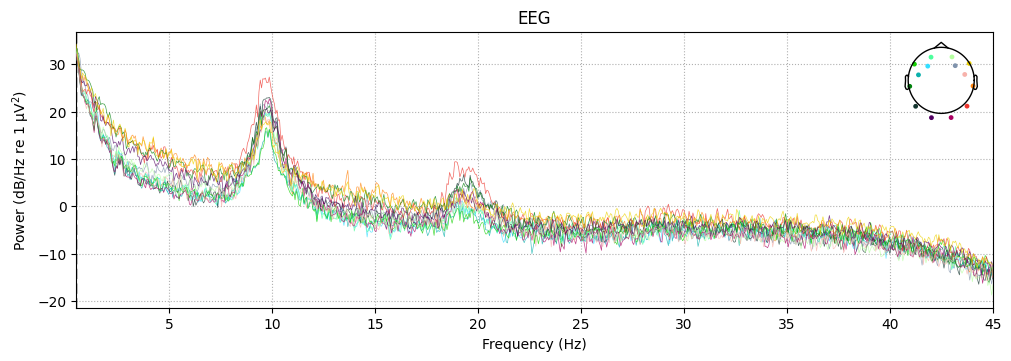

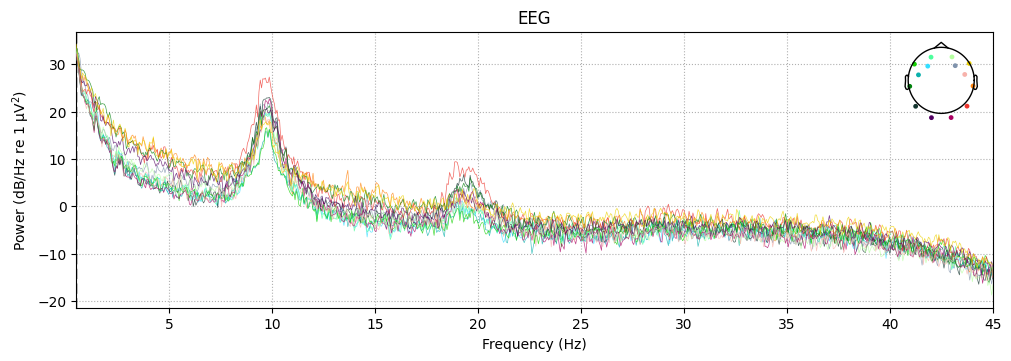

In [ ]:
# ============================================================
# VIS 1 — PSD (After Cleaning) (RUN)
# ============================================================
raw_final.compute_psd(fmin=0.5, fmax=45).plot()

# VIS-2. Channel-wise Mean Bandpower (Theta/Alpha/Beta) (RUN)

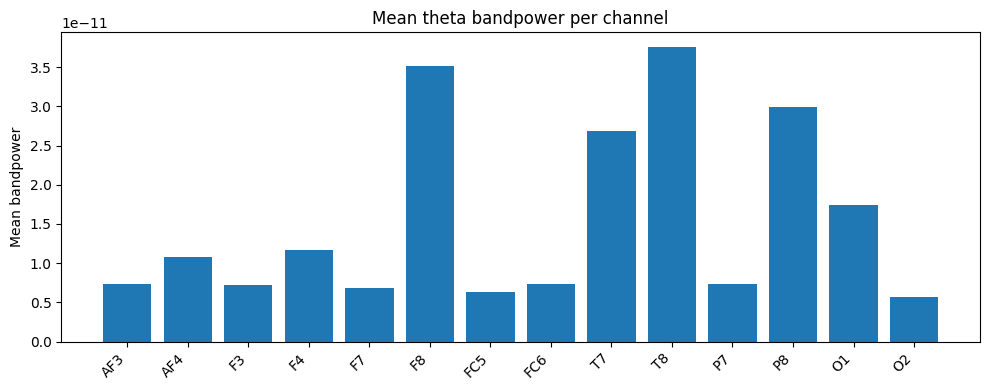

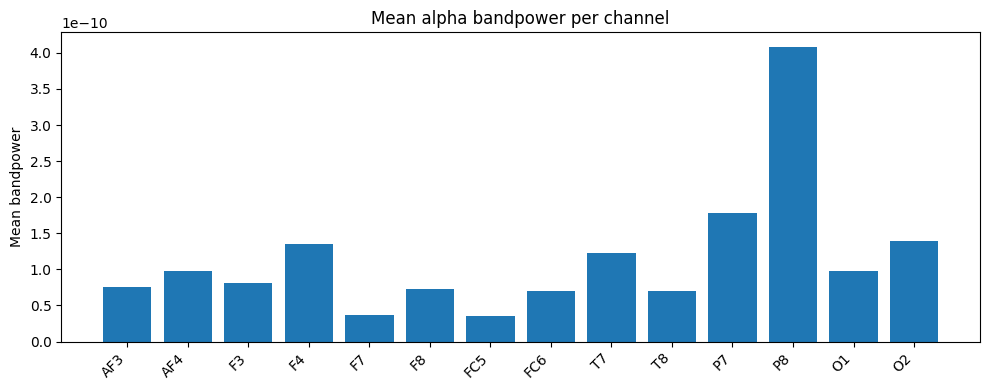

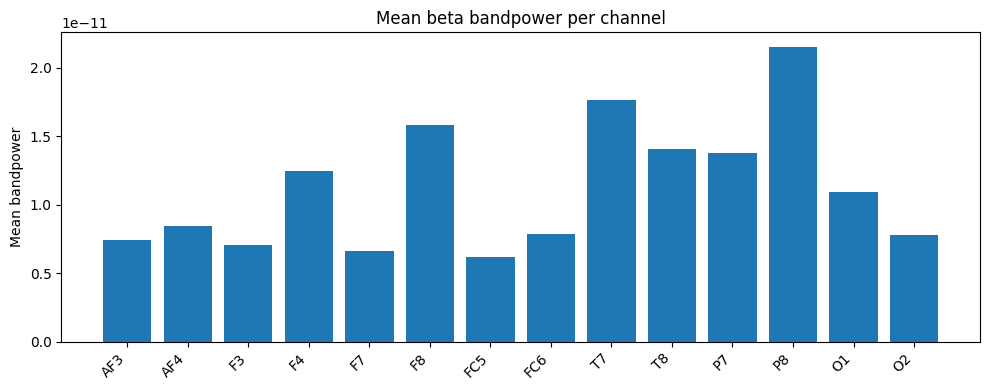

In [ ]:
# ============================================================
# VIS 2 — Channel-wise Mean Bandpower (Theta/Alpha/Beta) (RUN)
# ============================================================
channels = epochs_final.ch_names
for band in ["theta", "alpha", "beta"]:
    cols = [f"{ch}_{band}" for ch in channels if f"{ch}_{band}" in df_feat.columns]
    means = df_feat[cols].mean()

    plt.figure(figsize=(10, 4))
    plt.bar([c.split("_")[0] for c in cols], means.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean bandpower")
    plt.title(f"Mean {band} bandpower per channel")
    plt.tight_layout()
    plt.show()

# VIS-3. Bandpower Over Time (Example) (RUN)

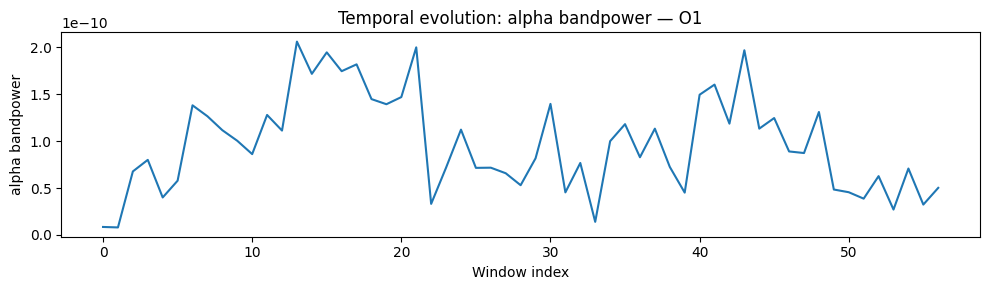

In [ ]:
# ============================================================
# VIS 3 — Bandpower Over Time (Example) (RUN)
# ============================================================
example_ch = "O1" if "O1" in channels else channels[0]
example_band = "alpha"
colname = f"{example_ch}_{example_band}"

plt.figure(figsize=(10, 3))
plt.plot(df_feat[colname].values)
plt.xlabel("Window index")
plt.ylabel(f"{example_band} bandpower")
plt.title(f"Temporal evolution: {example_band} bandpower — {example_ch}")
plt.tight_layout()
plt.show()

# VIS-4. Feature Correlation Heatmap (RUN)

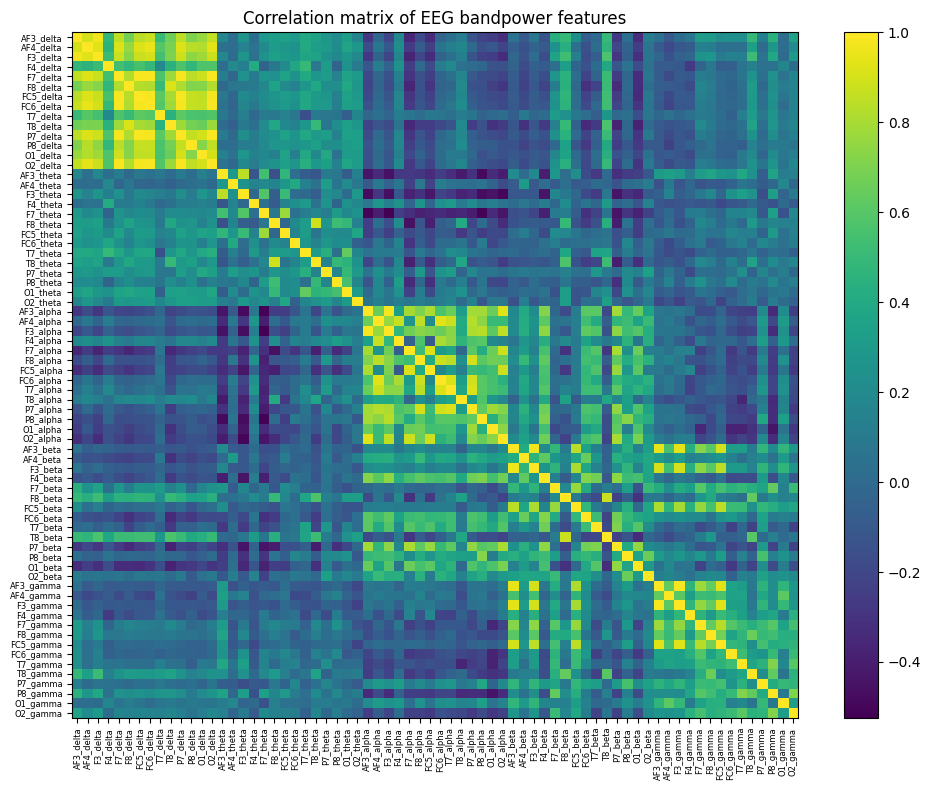

In [ ]:
# ============================================================
# VIS 4 — Feature Correlation Heatmap (RUN)
# ============================================================
corr = df_feat.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.title("Correlation matrix of EEG bandpower features")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.tight_layout()
plt.show()

# VIS-5. PCA (RUN)

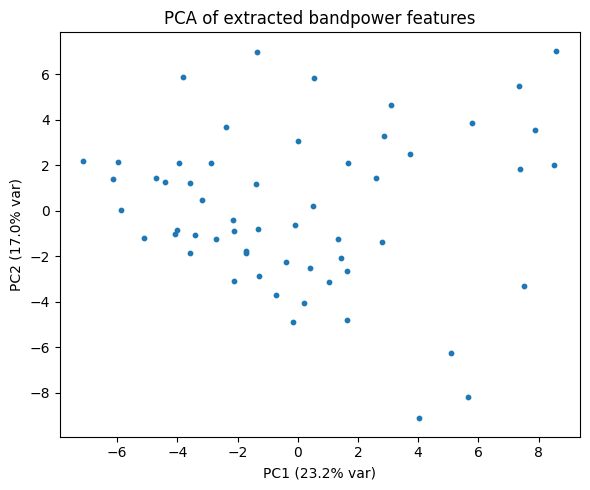

In [ ]:
# ============================================================
# VIS 5 — PCA (RUN)
# ============================================================
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(df_feat_z.values)

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], s=10)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of extracted bandpower features")
plt.tight_layout()
plt.show()

# VIS-6. SNR before vs after interpolation (RUN)

In [ ]:
print("raw_final channels:", raw_final.ch_names)
print("n_channels:", len(raw_final.ch_names))


raw_final channels: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
n_channels: 14


In [ ]:
# ============================================================
# SNR Analysis + Auto-fix low SNR channels (RUN)
# ============================================================

def epoch_band_snr_db(epochs, signal_band=(8, 30), noise_bands=((0.5, 2), (48, 52))):
    """Compute band SNR per channel using epoch-wise PSD, average across epochs."""
    psd = epochs.compute_psd(fmin=0.5, fmax=60.0)
    psds, freqs = psd.get_data(return_freqs=True)

    def bp(a, b):
        idx = (freqs >= a) & (freqs < b)
        return np.trapz(psds[:, :, idx], freqs[idx], axis=2)

    sig = bp(signal_band[0], signal_band[1])
    noi = np.zeros_like(sig)
    for a, b in noise_bands:
        a2 = max(a, 0.5)
        b2 = min(b, 60.0)
        if b2 > a2:
            noi += bp(a2, b2)

    snr = 10 * np.log10((sig + 1e-20) / (noi + 1e-20))
    return epochs.ch_names, snr.mean(axis=0)

# SNR before final interpolation
ch_pre, snr_pre = epoch_band_snr_db(epochs_0)
print("SNR before interpolation:")
print(pd.DataFrame({"channel": ch_pre, "snr_pre": snr_pre}))

# SNR after final processing
ch_fin, snr_fin = epoch_band_snr_db(epochs_final)
snr_df = pd.DataFrame({"channel": ch_fin, "snr": snr_fin}).sort_values("channel")
print("\nSNR after processing:")
print(snr_df)

avg_snr = snr_df["snr"].mean()
std_snr = snr_df["snr"].std()
print(f"\nAverage SNR: {avg_snr:.2f} dB ± {std_snr:.2f} dB")

# AUTO-FIX: Force interpolate very bad channels if average SNR is poor
if avg_snr < 0.0:
    low_snr_chs = snr_df[snr_df["snr"] < -2.5]["channel"].tolist()
    if low_snr_chs and len(low_snr_chs) <= 3:
        print(f"\nAUTO-FIX: Interpolating low SNR channels: {low_snr_chs}")
        raw_final.info["bads"] = low_snr_chs
        raw_final.interpolate_bads(reset_bads=True)

        # Re-annotate and re-epoch after interpolation
        raw_final = annotate_high_amplitude(raw_final, picks=raw_final.ch_names, 
                                          z_thresh=BADSEG_ZTHRESH, min_duration=BADSEG_MIN_DURATION, desc="BAD_amp")
        epochs_final_fixed = make_epochs_clean(raw_final)
        ch_fixed, snr_fixed = epoch_band_snr_db(epochs_final_fixed)
        print("SNR after auto-interpolation:")
        print(pd.DataFrame({"channel": ch_fixed, "snr_fixed": snr_fixed}))
        print("New average SNR:", snr_fixed.mean())
    else:
        print("\nNo auto-fix needed or too many bad channels.")
else:
    print("\nSNR good enough, no auto-fix needed.")

Setting 3562 of 46720 (7.62%) samples to NaN, retaining 43158 (92.38%) samples.
Effective window size : 16.000 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Setting 1362 of 46720 (2.92%) samples to NaN, retaining 45358 (97.08%) samples.
Effective window size : 16.000 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.


/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 62, using nperseg = 62
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 598, using nperseg = 598
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 865, using nperseg = 865
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1397, using nperseg = 1397
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 1318, using nperseg = 1318
  return _func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/mne/time_frequency

,channel,snr
0,AF3,-2.335660
1,AF4,-1.173485
2,F3,-1.541564
3,F4,-2.246218
4,F7,-2.799293
5,F8,-0.363694
6,FC5,-2.780953
7,FC6,-2.062327
12,O1,0.080293
13,O2,-0.347263


AVG SNR:

In [ ]:
snr_col = [c for c in snr_df.columns if "snr" in c.lower()][-1]
avg_snr = snr_df[snr_col].mean()
std_snr = snr_df[snr_col].std()

print(f"Using column: {snr_col}")
print(f"Average SNR: {avg_snr:.2f} dB ± {std_snr:.2f} dB")


Using column: snr
Average SNR: -0.89 dB ± 1.63 dB


# VIS-7. Drop Summary (RUN)

In [ ]:
# ============================================================
# VIS 6 — Drop Summary (RUN)
# ============================================================
# How many epochs were dropped and why
dropped = sum(len(x) > 0 for x in epochs_final.drop_log)
print("Dropped epochs:", dropped, "out of", len(epochs_final) + dropped)
print("Example drop reasons:", epochs_final.drop_log[:dropped])

Dropped epochs: 33 out of 90
Example drop reasons: ((), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (np.str_('BAD_amp'),), (np.str_('BAD_amp'),), (), (np.str_('BAD_amp'),), (np.str_('BAD_amp'),), (), (), (), (), (), (np.str_('BAD_amp'),))


# VIS-8. PSD Before and After

BEFORE

In [ ]:
import mne

# Load raw .set (BEFORE preprocessing)
raw_before = mne.io.read_raw_eeglab(
    "/content/drive/MyDrive/EEG/S4EDFN.set",  # change filename
    preload=True
)

raw_before.pick("eeg")

# Optional: resample for fair comparison
raw_before.resample(128)

print("Before preprocessing:")
print(raw_before)


Reading /content/drive/MyDrive/EEG/S4EDFN.fdt
Reading 0 ... 46719  =      0.000 ...   364.992 secs...
Sampling frequency of the instance is already 128.0, returning unmodified.
Before preprocessing:
<RawEEGLAB | S4EDFN.fdt, 14 x 46720 (365.0 s), ~5.0 MiB, data loaded>


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


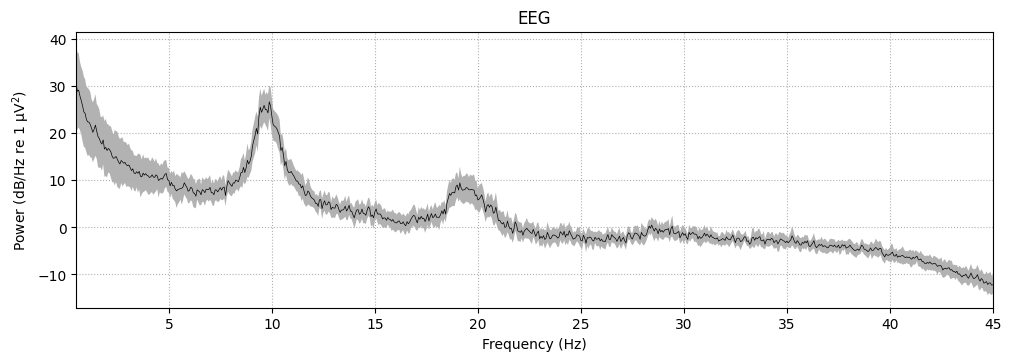

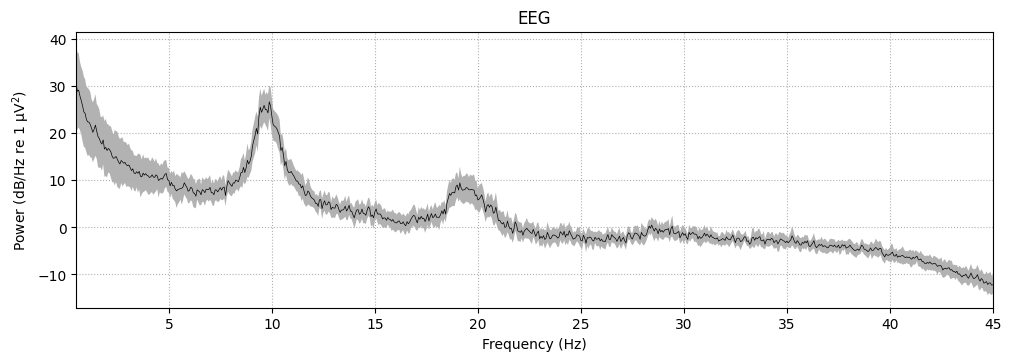

In [ ]:
raw_before.compute_psd(
    fmin=0.5,
    fmax=45,
    method="welch"
).plot(
    average=True,
    spatial_colors=True,
    show=True
)


AFTER

In [ ]:
raw_after = mne.io.read_raw_fif(
    "/content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif",
    preload=True
)

raw_after.pick("eeg")

print("After preprocessing:")
print(raw_after)


Opening raw data file /content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif...
    Range : 0 ... 46719 =      0.000 ...   364.992 secs
Ready.
Reading 0 ... 46719  =      0.000 ...   364.992 secs...
After preprocessing:
<Raw | S4EDFN_clean_raw_ICA.fif, 14 x 46720 (365.0 s), ~5.0 MiB, data loaded>


/tmp/ipython-input-4019674008.py:1: RuntimeWarning: This filename (/content/drive/MyDrive/EEG_processed_auto/S4EDFN_clean_raw_ICA.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


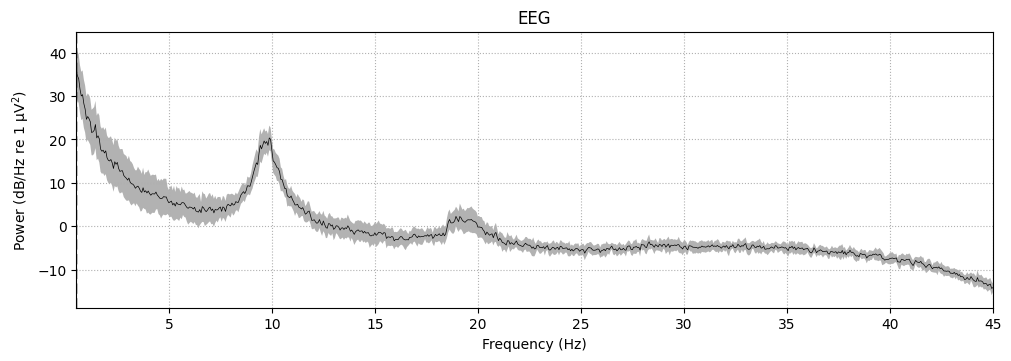

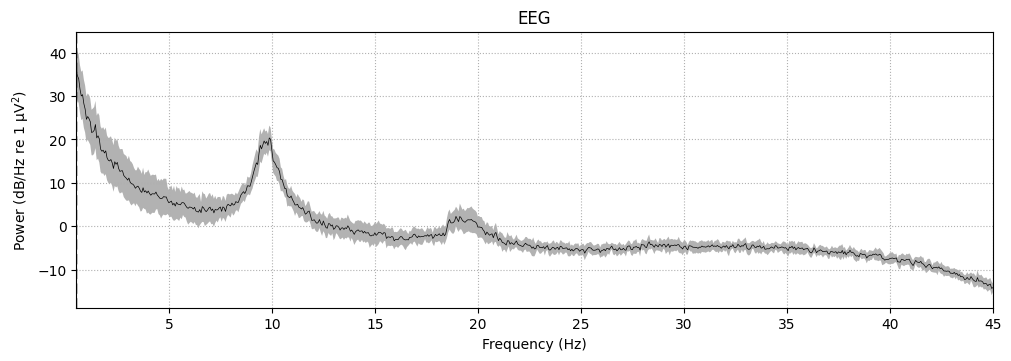

In [ ]:
raw_after.compute_psd(
    fmin=0.5,
    fmax=45,
    method="welch"
).plot(
    average=True,
    spatial_colors=True,
    show=True
)


Side by Side

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


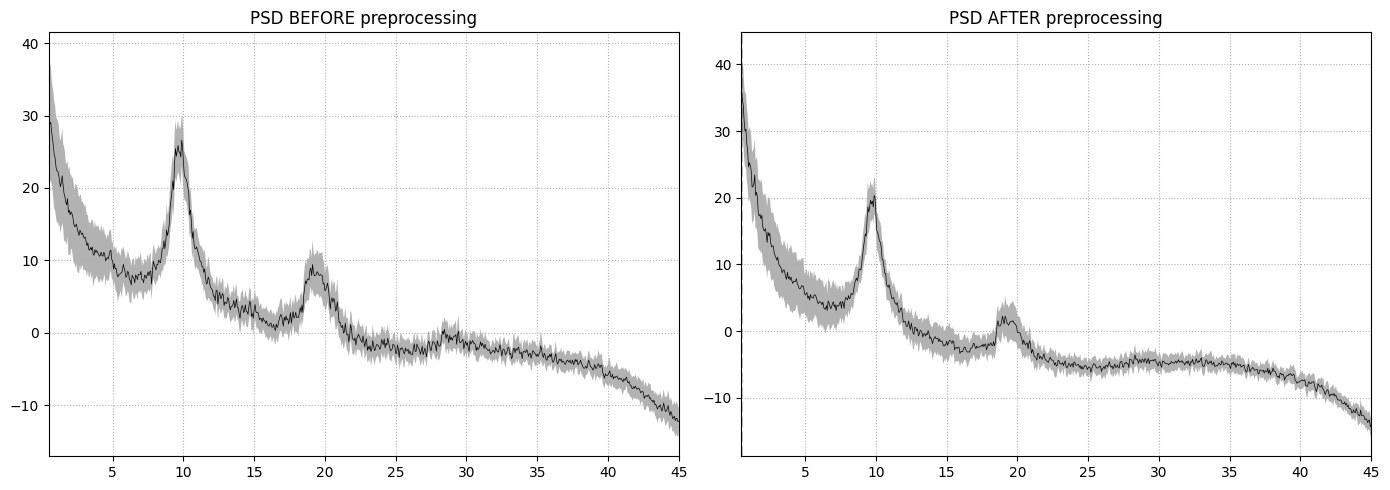

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_before.compute_psd(fmin=0.5, fmax=45).plot(
    axes=axes[0],
    average=True,
    spatial_colors=False,
    show=False
)
axes[0].set_title("PSD BEFORE preprocessing")

raw_after.compute_psd(fmin=0.5, fmax=45).plot(
    axes=axes[1],
    average=True,
    spatial_colors=False,
    show=False
)
axes[1].set_title("PSD AFTER preprocessing")

plt.tight_layout()
plt.show()
